# Fitting Curves: Concepts

What you'll do:

- Answer questions about what a GP is, and its relationship to GLMs and splines.
- Practice applying each of: polynomial modeling, b splines, and GPs
- You'll get a chance to read about and try to comprehend a more standard implementation of a GP.

Have fun!

**Task1**:

Why would you ever want to include a polynomial element in a model you built? What's the benefit of using polynomials to model?

**The benefit of using polynomials to model is when the relationship between variables is not linear and more complicated, therefore improving predictive performance.**

**Task2**:

Why would you ever NOT want to include a polynomial element in a model you built?

**It can cause overfitting and poor extrapolation of the data. If it doesn't improve a simpler model, it is best not to include a polynomial element.**

**Task3**:

What's the point of using b splines?

**They model nonlinear relationships without the greater instability of a polynomial model, reducing overfitting and handling extrapolation better.**

**Task4**:

Describe what a Gaussian Process is, in your own words. *Don't worry about being correct, just try to explain it to yourself*. I will not grade this question for accuracy.

**Instead of guessing one function that might fit the data, a Gaussian Process puts a probability distribution over all the functions that might fit.**

**Task5**:

Fit three models to the howell data (from Unit5ExercisesSF): polynomial, b splines, and Gaussian Process.

Plot the posterior predictive check on a scatter plot, as is standard/required.

Hint: Distributional models (variable variance) work better on the howell data.


In [ ]:
!pip install preliz
!pip install bambi

In [2]:
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
import preliz as pz
import pymc as pm
import bambi as bmb

In [3]:
howell = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/refs/heads/main/Data/howell.csv')

In [4]:
howell

,height,weight,age,male
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0
...,...,...,...,...
539,145.415,31.127751,17.0,1
540,162.560,52.163080,31.0,1
541,156.210,54.062497,21.0,0
542,71.120,8.051258,0.0,1


In [ ]:
#degree 4 polynomial model
model_poly_4 = bmb.Model("weight ~ poly(height, degree=4)", howell)
idata_poly_4 = model_poly_4.fit()

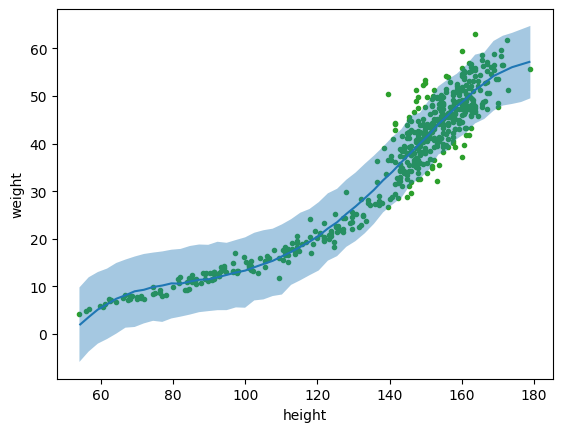

In [18]:
#plot of posterior predictive dist
bmb.interpret.plot_predictions(model_poly_4, idata_poly_4, "height", pps=True)
#raw data
plt.plot(howell.height, howell.weight, "C2.", zorder=-3)

In [ ]:
#bspline
num_knots = 6
min_height = howell["height"].min()
max_height = howell["height"].max()
knots = np.linspace(min_height, max_height, num_knots+2)[1:-1]
model_spline = bmb.Model("weight ~ bs(height, degree=3, knots=knots)", howell)
idata_spline = model_spline.fit()

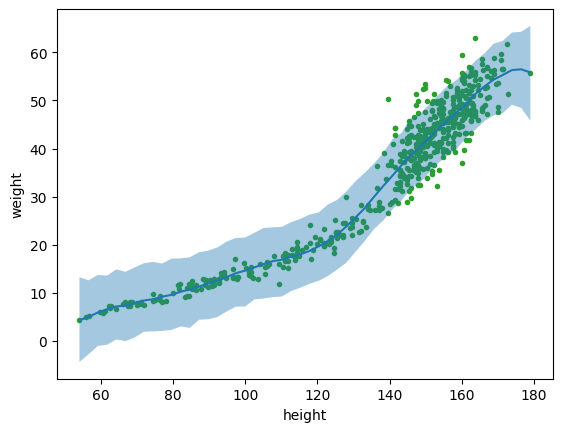

In [20]:
bmb.interpret.plot_predictions(model_spline, idata_spline, "height", pps= True)
plt.plot(howell.height, howell.weight, "C2.", zorder=-3)

In [9]:
#convert from pandas to numpy array
weight = howell["weight"].values
height = howell["height"].values[:,None]

In [10]:
#ig stands for inverse gamma
def get_ig_params(x_vals, l_b=None, u_b=None, mass=0.96, plot=False):
    """
    Returns a weakly informative prior for the length-scale parameter of the GP kernel.
    """

    differences = np.abs(np.subtract.outer(x_vals, x_vals))
    if l_b is None:
        l_b = np.min(differences[differences != 0]) * 2
    if u_b is None:
        u_b = np.max(differences) / 1.5

    dist = pz.InverseGamma()
    pz.maxent(dist, l_b, u_b, mass, plot=plot)

    return dict(zip(dist.param_names, dist.params))

In [15]:
m, c = pm.gp.hsgp_approx.approx_hsgp_hyperparams(
    x_range=[0, 180], lengthscale_range=[1, 70], cov_func="ExpQuad"
)

print("Recommended smallest number of basis vectors (m):", m)
print("Recommended smallest scaling factor (c):", np.round(c, 1))

Recommended smallest number of basis vectors (m): 392
Recommended smallest scaling factor (c): 2.5


In [ ]:
prior_gp = {
    "sigma": bmb.Prior("Gamma", mu=1, sigma=0.01),
    "ell": bmb.Prior("InverseGamma", **get_ig_params(height))
}

priors = {
    "hsgp(height, m=392, c=2.5)": prior_gp,
    "alpha": bmb.Prior("HalfNormal", sigma=1)
}

model_hsb = bmb.Model("weight ~ 0 + hsgp(height, m=168, c=8.0)", howell, priors=priors)
idata_hsb = model_hsb.fit()

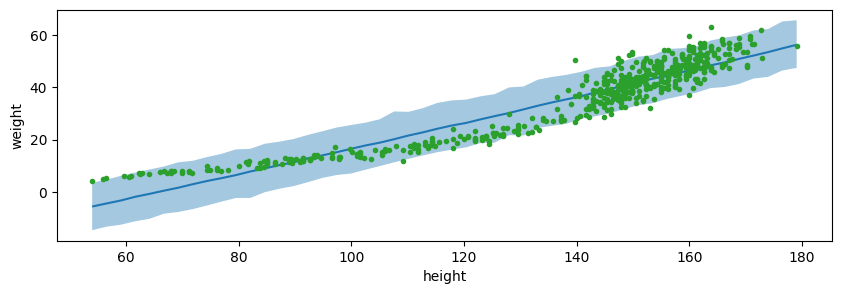

In [27]:
_, ax = bmb.interpret.plot_predictions(model_hsb, idata_hsb, ["height"],
                                       pps = True,
                                       fig_kwargs={"figsize": (10, 3)})
ax[0].plot(howell["height"].values, howell["weight"].values, "C2.")

**Task6**:

Read the article on the pymc website about GP implementation on the Mauna Loa CO$_{2}$ data combined with CO$_{2}$ ice core data from the south pole.
[Link here.](https://www.pymc.io/projects/examples/en/latest/gaussian_processes/GP-MaunaLoa2.html)

Write down one thing you learned about GPs from reading the article.

Note: You probably won't understand much in this article--I had to read it about five times before I figured out what was going on. The points of this task are to: hammer home that good GP implementations are extremely technical, and increasure your exposure to the kinds of problems traditional GPs are good at solving.

**I learned that you can complicate the model more by using semiparametric and changepoint GPs.**

**Task7**:

Describe your favorite graph from the article in the previous task with as much technical detail as you can muster.

Explain why its your favorite.

**My favorite graph is the one that models fit and possible forecasts based on year predicting CO2 levels. It is zoomed in around 400 ppm, showing how the predictions are much better using the changepoint model. It is my favorite because I thought the shape looked cool, and I could visually see a difference in prediction.**